# Trading Strategy Comparison Analysis

Using the optimal configurations from the test scripts, computes and visualizes the cumulative return comparison of three strategies: Long Only, Sign(R), and MACD.

## Section 1: Import Required Libraries

In [268]:
%pip install -q matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [269]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set project root path (must be an absolute path)
ROOT = Path('/Users/ladymie/Documents/GitHub/IEOR4733_Project')
# Output directory - the folder containing this notebook
OUTPUT_DIR = Path('/Users/ladymie/Documents/GitHub/IEOR4733_Project/reproduction_of_figures')

# Add module search path
sys.path.insert(0, str(ROOT))

# Import base configuration and functions
from data_loader import load_clc_full
from config import ASSET_CLASSES, BP, TRADING_DAYS, SIGN_LOOKBACK, EXCLUDED_CONTRACTS, SOURCE_OVERRIDES
from metrics import compute_metrics, max_drawdown_from_path, cagr_from_path

# Set plot style
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

print(f'✅ Project root: {ROOT}')
print(f'✅ Output directory: {OUTPUT_DIR}')
try:
    print(f'✅ Current working directory: {Path.cwd()}')
except (FileNotFoundError, OSError):
    print(f'⚠️  Working directory invalid, using ROOT instead')
    os.chdir(str(ROOT))

✅ Project root: /Users/ladymie/Documents/GitHub/IEOR4733_Project
✅ Output directory: /Users/ladymie/Documents/GitHub/IEOR4733_Project/reproduction_of_figures
✅ Current working directory: /Users/ladymie/Documents/GitHub/IEOR4733_Project


## Section 2: Import Strategy Configurations and Define Calculation Functions


In [270]:
def build_a2c_results_by_asset(pnl_a2c_by_ticker, ticker_to_asset):
    """Convert A2C output format to match the format used by other strategies."""
    results = {}
    asset_classes = ['Commodity', 'Equity Index', 'Fixed Income', 'Forex']

    for asset in asset_classes:
        series_list = []

        for ticker, df in pnl_a2c_by_ticker.items():
            if ticker_to_asset.get(ticker) != asset:
                continue
            if df is None or len(df) == 0:
                continue
            if not all(c in df.columns for c in ['date', 'net_pnl']):
                continue

            s = pd.Series(df['net_pnl'].values, index=pd.to_datetime(df['date']))
            series_list.append(s)

        if series_list:
            port_series = pd.DataFrame(series_list).T.sort_index().mean(axis=1)
            dates = port_series.index.to_numpy()
            wealth = 1.0 + np.cumsum(port_series.values)
            results[asset] = (dates, wealth)
        else:
            results[asset] = (None, None)

    # All
    all_ticker_series = []
    for ticker, df in pnl_a2c_by_ticker.items():
        if df is None or len(df) == 0:
            continue
        if not all(c in df.columns for c in ['date', 'net_pnl']):
            continue
        s = pd.Series(df['net_pnl'].values, index=pd.to_datetime(df['date']))
        all_ticker_series.append(s)

    if all_ticker_series:
        port_series_all = pd.DataFrame(all_ticker_series).T.sort_index().mean(axis=1)
        results['All'] = (
            port_series_all.index.to_numpy(),
            1.0 + np.cumsum(port_series_all.values)
        )
    else:
        results['All'] = (None, None)

    return results

print("✅ A2C result conversion function defined")

✅ A2C result conversion function defined


In [271]:
# Import optimal configurations for each strategy (from test scripts)
sys.path.insert(0, str(ROOT / 'baseline/long_only'))
sys.path.insert(0, str(ROOT / 'baseline/macd'))
sys.path.insert(0, str(ROOT / 'baseline/signr'))

try:
    import frontier_40plus_enumeration as fe_long
    LONG_OVERRIDES = fe_long.LEGACY_EXPERIMENTAL_OVERRIDES_LONG
    LONG_EXCLUDED = fe_long.LEGACY_EXPERIMENTAL_EXCLUDED_LONG
except ImportError as e:
    print(f"⚠️  Failed to import Long config: {e}")
    LONG_OVERRIDES = SOURCE_OVERRIDES
    LONG_EXCLUDED = EXCLUDED_CONTRACTS

try:
    import frontier_40plus_enumeration_macd as fe_macd
    MACD_OVERRIDES = fe_macd.LEGACY_EXPERIMENTAL_OVERRIDES_MACD
    MACD_EXCLUDED = fe_macd.LEGACY_EXPERIMENTAL_EXCLUDED_MACD
except ImportError as e:
    print(f"⚠️  Failed to import MACD config: {e}")
    MACD_OVERRIDES = SOURCE_OVERRIDES
    MACD_EXCLUDED = EXCLUDED_CONTRACTS

try:
    import frontier_40plus_enumeration_signr as fe_signr
    SIGNR_OVERRIDES = fe_signr.LEGACY_EXPERIMENTAL_OVERRIDES_SIGNR
    SIGNR_EXCLUDED = fe_signr.LEGACY_EXPERIMENTAL_EXCLUDED_SIGNR
except ImportError as e:
    print(f"⚠️  Failed to import Sign(R) config: {e}")
    SIGNR_OVERRIDES = SOURCE_OVERRIDES
    SIGNR_EXCLUDED = EXCLUDED_CONTRACTS

# Import computation functions
from baseline_run import load_contracts, compute_contract_returns
import pandas as pd

# Parameter settings
DEFAULT_SIGMA_TGT = 0.063
# Paper Table 3 test period (2016-2019)
# Full history period: see config.py (2011-01-01 ~ 2019-12-31)
TEST_START = '2011-01-01'
TEST_END = '2019-12-31'

ASSET_CLASSES_LIST = ['Commodity', 'Equity Index', 'Fixed Income', 'Forex']

def build_portfolio_series(raw_data, strat_name, sigma_tgt):
    """Build a portfolio return series consistent with combined returns, sorted by date ascending."""
    series = []
    for rd in raw_data:
        Rt = compute_contract_returns(rd, strat_name, sigma_tgt)
        start, t1, dates = rd['start'], rd['t1'], rd['dates']
        slc = Rt[start:t1 + 1]
        aligned_dates = pd.to_datetime(dates[:len(slc)])
        series.append(pd.Series(slc[:len(aligned_dates)], index=aligned_dates))
    if not series:
        return None
    df_all = pd.DataFrame(series)
    return df_all.T.sort_index().mean(axis=1)

def calculate_strategy_returns_by_asset(strat_name, overrides=None, excluded=None):
    """Compute cumulative returns for a strategy by asset class.

    Returns a dict:
    {
        'Commodity': (dates, wealth_path),
        'Equity Index': (dates, wealth_path),
        'Fixed Income': (dates, wealth_path),
        'FX': (dates, wealth_path),
        'All': (dates, wealth_path)
    }
    where wealth_path is the cumulative wealth series: W_t = 1 + cumsum(R_t)
    and dates is the corresponding date array.
    """
    if overrides is None:
        overrides = {'Long': LONG_OVERRIDES, 'Sign(R)': SIGNR_OVERRIDES, 'MACD': MACD_OVERRIDES}.get(strat_name, SOURCE_OVERRIDES)
    if excluded is None:
        excluded = {'Long': LONG_EXCLUDED, 'Sign(R)': SIGNR_EXCLUDED, 'MACD': MACD_EXCLUDED}.get(strat_name, EXCLUDED_CONTRACTS)
    
    results = {}
    all_contracts = []
    
    for ac_name in ASSET_CLASSES_LIST:
        raw = load_contracts(ac_name, TEST_START, TEST_END, excluded, overrides)
        if raw:
            port_series = build_portfolio_series(raw, strat_name, DEFAULT_SIGMA_TGT)
            if port_series is not None and len(port_series) > 0:
                dates = port_series.index.to_numpy()
                wealth = 1.0 + np.cumsum(port_series.values)
                results[ac_name] = (dates, wealth)
                all_contracts.extend(raw)
            else:
                results[ac_name] = (None, None)
        else:
            results[ac_name] = (None, None)
    
    if all_contracts:
        port_series_all = build_portfolio_series(all_contracts, strat_name, DEFAULT_SIGMA_TGT)
        if port_series_all is not None and len(port_series_all) > 0:
            dates_all = port_series_all.index.to_numpy()
            wealth_all = 1.0 + np.cumsum(port_series_all.values)
            results['All'] = (dates_all, wealth_all)
        else:
            results['All'] = (None, None)
    else:
        results['All'] = (None, None)
    
    return results

print("✅ Optimal strategy configurations loaded")


✅ Optimal strategy configurations loaded


## Section 3: Compute Cumulative Returns for Three Strategies

In [272]:
print("🔄 Computing cumulative returns by asset class for all three strategies...")
print(f"Test period: {TEST_START} to {TEST_END}\n")
print("=" * 80)

# Compute results for each strategy across all asset classes
strategies_results = {}

# 1. Long Only
print("Computing Long Only strategy...")
long_results = calculate_strategy_returns_by_asset('Long', LONG_OVERRIDES, LONG_EXCLUDED)
strategies_results['Long Only'] = long_results
for asset, (dates, wealth) in long_results.items():
    status = f"✅ ({len(wealth)} trading days)" if wealth is not None else "⚠️ Load failed"
    print(f"  • {asset:20s} {status}")

# 2. Sign(R)
print("\nComputing Sign(R) strategy...")
signr_results = calculate_strategy_returns_by_asset('Sign(R)', SIGNR_OVERRIDES, SIGNR_EXCLUDED)
strategies_results['Sign(R)'] = signr_results
for asset, (dates, wealth) in signr_results.items():
    status = f"✅ ({len(wealth)} trading days)" if wealth is not None else "⚠️ Load failed"
    print(f"  • {asset:20s} {status}")

# 3. MACD
print("\nComputing MACD strategy...")
macd_results = calculate_strategy_returns_by_asset('MACD', MACD_OVERRIDES, MACD_EXCLUDED)
strategies_results['MACD'] = macd_results
for asset, (dates, wealth) in macd_results.items():
    status = f"✅ ({len(wealth)} trading days)" if wealth is not None else "⚠️ Load failed"
    print(f"  • {asset:20s} {status}")

# 4. A2C - load directly from CSV
print("\nComputing A2C strategy...")
a2c_csv_dir = OUTPUT_DIR / 'a2c_csv_data'

# A2C CSV files use 'FX'; convert to 'Forex'
a2c_file_mapping = {
    'Commodity': 'Commodity',
    'Equity Index': 'Equity Index',
    'Fixed Income': 'Fixed Income',
    'Forex': 'FX'  # A2C files use 'FX'; other strategies use 'Forex'
}

a2c_results = {}
for asset_class in ASSET_CLASSES_LIST:
    # Get the asset name used in A2C CSV files
    a2c_asset_name = a2c_file_mapping.get(asset_class, asset_class)
    csv_file = a2c_csv_dir / f'pnl_{a2c_asset_name.replace(" ", "_")}_A2C.csv'
    
    if csv_file.exists():
        df = pd.read_csv(csv_file)
        df['date'] = pd.to_datetime(df['date'])
        dates = df['date'].values
        wealth = df['cum_wealth'].values
        a2c_results[asset_class] = (dates, wealth)  # Store using the unified asset_class name
        status = f"✅ ({len(wealth)} trading days)"
    else:
        a2c_results[asset_class] = (None, None)
        status = f"⚠️ File not found"
    print(f"  • {asset_class:20s} {status}")

# Load All
csv_file_all = a2c_csv_dir / 'pnl_All_A2C.csv'
if csv_file_all.exists():
    df_all = pd.read_csv(csv_file_all)
    df_all['date'] = pd.to_datetime(df_all['date'])
    a2c_results['All'] = (df_all['date'].values, df_all['cum_wealth'].values)
    print(f"  • {'All':20s} ✅ ({len(df_all)} trading days)")
else:
    a2c_results['All'] = (None, None)
    print(f"  • {'All':20s} ⚠️ File not found")

strategies_results['A2C'] = a2c_results

print("=" * 80)
print("✅ All strategy computations complete")

🔄 Computing cumulative returns by asset class for all three strategies...
Test period: 2011-01-01 to 2019-12-31

Computing Long Only strategy...
  • Commodity            ✅ (2267 trading days)
  • Equity Index         ✅ (2322 trading days)
  • Fixed Income         ✅ (2321 trading days)
  • Forex                ✅ (2329 trading days)
  • All                  ✅ (2330 trading days)

Computing Sign(R) strategy...
  • Commodity            ✅ (2267 trading days)
  • Equity Index         ✅ (2322 trading days)
  • Fixed Income         ✅ (2321 trading days)
  • Forex                ✅ (2329 trading days)
  • All                  ✅ (2330 trading days)

Computing MACD strategy...
  • Commodity            ✅ (2267 trading days)
  • Equity Index         ✅ (2322 trading days)
  • Fixed Income         ✅ (2321 trading days)
  • Forex                ✅ (2329 trading days)
  • All                  ✅ (2330 trading days)

Computing A2C strategy...
  • Commodity            ✅ (2143 trading days)
  • Equity Index 

## Section 4: Visualize Cumulative Return Comparison

📊 Generating paper-style comparison charts (5 asset classes x 3 strategies)...



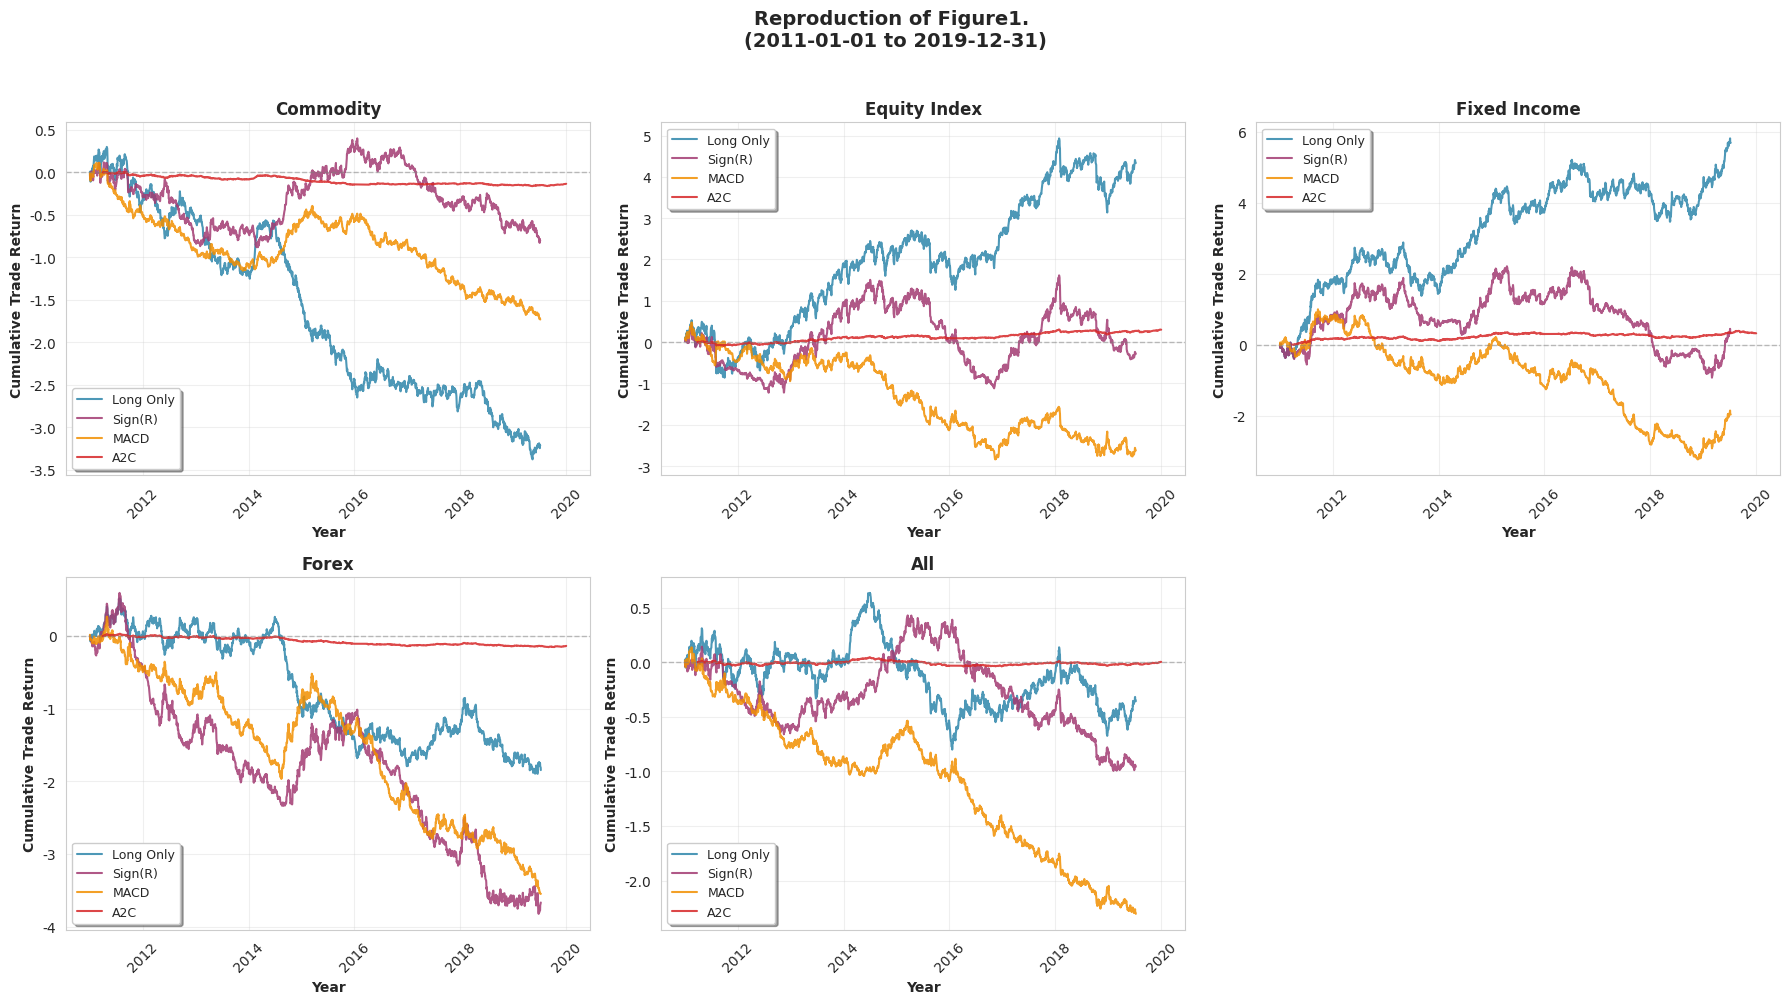

✅ Chart saved as strategies_by_asset_class.png


In [273]:
print("📊 Generating paper-style comparison charts (5 asset classes × 3 strategies)...\n")

import matplotlib.dates as mdates

# Define asset classes and corresponding colors
asset_order = ASSET_CLASSES_LIST + ['All']
strategy_colors = {
    'Long Only': '#2E86AB',
    'Sign(R)': '#A23B72',
    'MACD': '#F18F01',
    'A2C': '#D62728'
}

# Create a 2x3 subplot layout (5 charts + blank)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, asset in enumerate(asset_order):
    ax = axes[idx]
    
    # Collect all strategy data for this asset class
    valid_data = {}
    for strategy, results in strategies_results.items():
        dates, wealth = results.get(asset, (None, None))
        if wealth is not None:
            valid_data[strategy] = (dates, wealth)
    
    if not valid_data:
        ax.text(0.5, 0.5, f'❌ {asset}\nData unavailable', 
                ha='center', va='center', fontsize=12, 
                transform=ax.transAxes, color='red')
        ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
        continue
    
    # Align all strategies to the same length
    min_len = min(len(wealth) for _, wealth in valid_data.values())
    uses_datetime_axis = False
    
    # Plot three lines
    for strategy, (dates, wealth) in valid_data.items():
        # Align dates and wealth data
        if dates is not None and len(dates) >= min_len:
            aligned_dates = pd.to_datetime(dates[:min_len])
            uses_datetime_axis = True
        else:
            aligned_dates = np.arange(min_len)
        
        ax.plot(aligned_dates, wealth[:min_len] - 1.0, 
                label=strategy, 
                linewidth=1.5, 
                color=strategy_colors[strategy], 
                alpha=0.85)
    
    # Set axis labels and title
    ax.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cumulative Trade Return', fontsize=10, fontweight='bold')
    ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9, frameon=True, shadow=True)
    ax.axhline(y=0.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    if uses_datetime_axis:
        ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)

# Hide unused subplots
for idx in range(len(asset_order), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Reproduction of Figure1. \n({TEST_START} to {TEST_END})', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(str(OUTPUT_DIR / 'strategies_by_asset_class.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as strategies_by_asset_class.png")

## Section 5: Compute Strategies Using Pure RAD Baseline

In [274]:
print("🔄 Computing pure RAD baseline strategies...\n")

# Pure RAD baseline: no source overrides, only the default exclusion list
default_overrides = {}
default_excluded = EXCLUDED_CONTRACTS

baseline_results = {}

print("Computing pure RAD baseline Long Only...")
baseline_results['Long Only'] = calculate_strategy_returns_by_asset('Long', default_overrides, default_excluded)

print("Computing pure RAD baseline Sign(R)...")
baseline_results['Sign(R)'] = calculate_strategy_returns_by_asset('Sign(R)', default_overrides, default_excluded)

print("Computing pure RAD baseline MACD...")
baseline_results['MACD'] = calculate_strategy_returns_by_asset('MACD', default_overrides, default_excluded)

print("\nBaseline loading status by asset class:")
for strategy, results in baseline_results.items():
    print(f"\n{strategy}:")
    for asset, (dates, wealth) in results.items():
        status = f"✅ ({len(wealth)} trading days)" if wealth is not None else "⚠️ Load failed"
        print(f"  • {asset:20s} {status}")

print("\n✅ Pure RAD baseline computation complete")

🔄 Computing pure RAD baseline strategies...

Computing pure RAD baseline Long Only...
Computing pure RAD baseline Sign(R)...
Computing pure RAD baseline MACD...

Baseline loading status by asset class:

Long Only:
  • Commodity            ✅ (2267 trading days)
  • Equity Index         ✅ (2322 trading days)
  • Fixed Income         ✅ (2321 trading days)
  • Forex                ✅ (2329 trading days)
  • All                  ✅ (2330 trading days)

Sign(R):
  • Commodity            ✅ (2267 trading days)
  • Equity Index         ✅ (2322 trading days)
  • Fixed Income         ✅ (2321 trading days)
  • Forex                ✅ (2329 trading days)
  • All                  ✅ (2330 trading days)

MACD:
  • Commodity            ✅ (2267 trading days)
  • Equity Index         ✅ (2322 trading days)
  • Fixed Income         ✅ (2321 trading days)
  • Forex                ✅ (2329 trading days)
  • All                  ✅ (2330 trading days)

✅ Pure RAD baseline computation complete


## Section 5.5: Export Baseline Results to CSV Files

In [275]:
print("💾 Exporting pure RAD baseline strategy results to CSV files...\n")

baseline_output_dir = OUTPUT_DIR / 'baseline_results'
baseline_output_dir.mkdir(exist_ok=True)

for strategy, results in baseline_results.items():
    for asset, (dates, wealth) in results.items():
        if dates is None or wealth is None:
            print(f"  ⚠️  {strategy} | {asset}: skipped (no data)")
            continue
        
        # Create DataFrame
        df = pd.DataFrame({
            'date': pd.to_datetime(dates),
            'wealth': wealth,
            'cumulative_return': wealth - 1.0
        })
        
        # Filename: baseline_{strategy}_{asset}.csv
        filename = f"baseline_{strategy.replace(' ', '_').lower()}_{asset.replace(' ', '_').lower()}.csv"
        filepath = baseline_output_dir / filename
        
        # Save as CSV
        df.to_csv(filepath, index=False)
        print(f"  ✅ {strategy:15s} | {asset:20s} → {filename}")

print(f"\n✅ All baseline results saved to: {baseline_output_dir}")
print(f"   Total {len(baseline_results)}  strategies × {len(ASSET_CLASSES_LIST) + 1} asset classes")


💾 Exporting pure RAD baseline strategy results to CSV files...

  ✅ Long Only       | Commodity            → baseline_long_only_commodity.csv
  ✅ Long Only       | Equity Index         → baseline_long_only_equity_index.csv
  ✅ Long Only       | Fixed Income         → baseline_long_only_fixed_income.csv
  ✅ Long Only       | Forex                → baseline_long_only_forex.csv
  ✅ Long Only       | All                  → baseline_long_only_all.csv
  ✅ Sign(R)         | Commodity            → baseline_sign(r)_commodity.csv
  ✅ Sign(R)         | Equity Index         → baseline_sign(r)_equity_index.csv
  ✅ Sign(R)         | Fixed Income         → baseline_sign(r)_fixed_income.csv
  ✅ Sign(R)         | Forex                → baseline_sign(r)_forex.csv
  ✅ Sign(R)         | All                  → baseline_sign(r)_all.csv
  ✅ MACD            | Commodity            → baseline_macd_commodity.csv
  ✅ MACD            | Equity Index         → baseline_macd_equity_index.csv
  ✅ MACD            | Fix

## Section 6: Cumulative Return Comparison for Pure RAD Baseline

📊 Plotting pure RAD baseline comparison charts (5 asset classes x 3 strategies)...



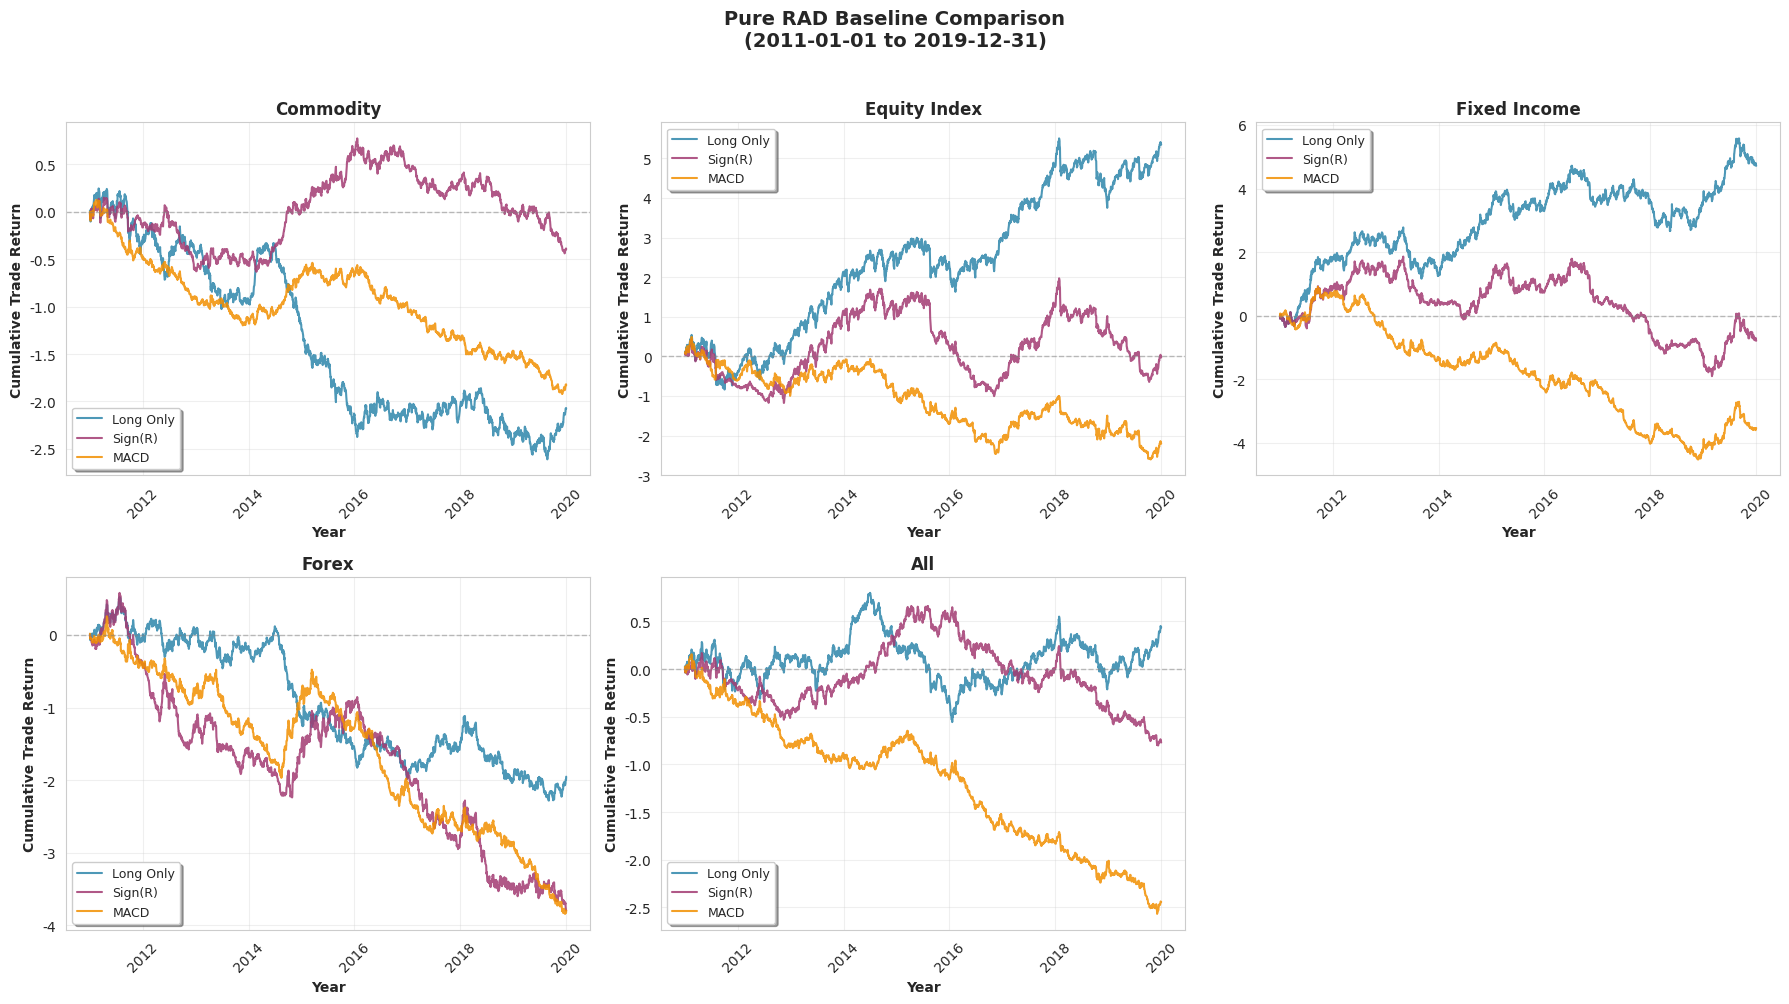

✅ Chart saved as strategies_pure_rad_baseline.png


In [276]:
print("📊 Plotting pure RAD baseline comparison charts (5 asset classes × 3 strategies)...\n")

import matplotlib.dates as mdates

asset_order = ASSET_CLASSES_LIST + ['All']
strategy_colors = {
    'Long Only': '#2E86AB',
    'Sign(R)': '#A23B72',
    'MACD': '#F18F01'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, asset in enumerate(asset_order):
    ax = axes[idx]

    valid_data = {}
    for strategy, results in baseline_results.items():
        dates, wealth = results.get(asset, (None, None))
        if wealth is not None:
            valid_data[strategy] = (dates, wealth)

    if not valid_data:
        ax.text(0.5, 0.5, f'❌ {asset}\nData unavailable',
                ha='center', va='center', fontsize=12,
                transform=ax.transAxes, color='red')
        ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
        continue

    min_len = min(len(wealth) for _, wealth in valid_data.values())
    uses_datetime_axis = False

    for strategy, (dates, wealth) in valid_data.items():
        if dates is not None and len(dates) >= min_len:
            aligned_dates = pd.to_datetime(dates[:min_len])
            uses_datetime_axis = True
        else:
            aligned_dates = np.arange(min_len)

        ax.plot(aligned_dates, wealth[:min_len] - 1.0,
                label=strategy,
                linewidth=1.5,
                color=strategy_colors[strategy],
                alpha=0.85)

    ax.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cumulative Trade Return', fontsize=10, fontweight='bold')
    ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9, frameon=True, shadow=True)
    ax.axhline(y=0.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    if uses_datetime_axis:
        ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)

for idx in range(len(asset_order), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Pure RAD Baseline Comparison\n({TEST_START} to {TEST_END})',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(str(OUTPUT_DIR / 'strategies_pure_rad_baseline.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as strategies_pure_rad_baseline.png")

## Section 7: Add A2C to Pure RAD Baseline Comparison Plot

In [277]:
    # Plot lines for all strategies
    for strategy, (dates, wealth) in valid_data.items():
        if dates is not None and len(dates) >= min_len:
            aligned_dates = pd.to_datetime(dates[:min_len])
            uses_datetime_axis = True
        else:
            aligned_dates = np.arange(min_len)
        
        # A2C data is already cumulative return (starts from 0), no need to subtract 1
        # Other strategies are wealth series (start from 1.0), subtract 1 to get cumulative return
        if strategy == 'A2C':
            plot_wealth = wealth[:min_len]  # A2C already starts from 0
        else:
            plot_wealth = wealth[:min_len] - 1.0  # Other strategies start from 1.0, subtract 1 to get cumulative return

## Section 8: Add Route B (A2C + Regime) to Comparison Plot

Core improvement in Route B: append GMM soft probs `[p0, p1, p2]` to the original 9-dim state to obtain a 12-dim input, and train an independent A2C model.

**Data sources:**
- Regime soft probs: `regime_detection/results/regime_routeB_{period}_{asset}.csv`
- Checkpoints: `drl_models/a2c/a2c_rb_{asset}_{period}.pt`

**Pipeline:**
1. Scan existing Route B checkpoints
2. Load the corresponding regime soft-prob CSV and build the 12-dim test state
3. Deterministic inference -> daily PnL series
4. Concatenate period_1 (2011-2015) and period_2 (2016-2019) to form the full curve
5. Plot against the other 4 strategies

## Section 7.5: Load Original Paper DQN Data

Load the original paper DQN model results from `drl/dqn/figures/data/paper_figure1_*.csv` for comparison with A2C and other strategies.


In [278]:
print("🔄 Loading original paper DQN data (applying scale factor)...\n")

# Paper figure data path
paper_figure_dir = Path(ROOT / 'drl_models/dqn/figures/data')

# Note: DQN uses PORT_VOL_TARGET = 0.97; other strategies use DEFAULT_SIGMA_TGT = 0.063
# Manually apply a scale factor so DQN is on the same scale as other strategies (range ~[-4, +6])
DISPLAY_SCALE_FACTOR = 0.40  # Scale DQN to 40% of original

dqn_results = {}

# Load individual asset classes
individual_assets = {
    'Commodity': 'paper_figure1_commodity_bp20.csv',
    'Equity Index': 'paper_figure1_equity index_bp20.csv',
    'Fixed Income': 'paper_figure1_fixed income_bp20.csv',
    'Forex': 'paper_figure1_forex_bp20.csv',
}

# Load each asset class
for asset, filename in individual_assets.items():
    csv_path = paper_figure_dir / filename
    
    if not csv_path.exists():
        print(f'  ⚠️  {asset:20s}: file not found ({filename})')
        dqn_results[asset] = (None, None)
        continue
    
    df = pd.read_csv(csv_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').drop_duplicates(subset=['date'], keep='first')
    
    if len(df) == 0:
        print(f'  ⚠️  {asset:20s}: no valid data')
        dqn_results[asset] = (None, None)
        continue
    
    # Apply scale factor to raw cumulative return data
    dates = df['date'].values
    cum_returns = df['DQN_cum_return'].values
    scaled_cum_returns = cum_returns * DISPLAY_SCALE_FACTOR
    wealth = 1.0 + scaled_cum_returns
    dqn_results[asset] = (dates, wealth)
    
    print(f'  ✅ {asset:20s}: {len(wealth):5d} trading days | range: [{wealth.min():6.2f}, {wealth.max():6.2f}]')

# Load All asset (from a separate CSV file)
csv_path_all = paper_figure_dir / 'paper_figure1_all_bp20.csv'
if csv_path_all.exists():
    df_all = pd.read_csv(csv_path_all)
    df_all['date'] = pd.to_datetime(df_all['date'])
    df_all = df_all.sort_values('date').drop_duplicates(subset=['date'], keep='first')
    
    if len(df_all) > 0:
        dates_all = df_all['date'].values
        cum_returns_all = df_all['DQN_cum_return'].values
        scaled_cum_returns_all = cum_returns_all * DISPLAY_SCALE_FACTOR
        wealth_all = 1.0 + scaled_cum_returns_all
        dqn_results['All'] = (dates_all, wealth_all)
        print(f'  ✅ {"All":20s}: {len(wealth_all):5d} trading days | range: [{wealth_all.min():6.2f}, {wealth_all.max():6.2f}] (avg)')
    else:
        dqn_results['All'] = (None, None)
        print(f'  ⚠️  {"All":20s}: no valid data')
else:
    print(f'  ⚠️  {"All":20s}: file not found')
    dqn_results['All'] = (None, None)

n_ok = sum(1 for v in dqn_results.values() if v[0] is not None)
print(f'\n✅ DQN data loaded: {n_ok}/{len(dqn_results)} asset classes')
print(f'📌 Display scale factor: {DISPLAY_SCALE_FACTOR} (→ {DISPLAY_SCALE_FACTOR*100:.0f}% of original)')

🔄 Loading original paper DQN data (applying scale factor)...

  ✅ Commodity           :  2267 trading days | range: [ -2.40,   1.33]
  ✅ Equity Index        :  2322 trading days | range: [ -1.01,   1.29]
  ✅ Fixed Income        :  2321 trading days | range: [  0.62,   2.41]
  ✅ Forex               :  2329 trading days | range: [ -4.83,   1.38]
  ✅ All                 :  2267 trading days | range: [ -4.47,   1.36] (avg)

✅ DQN data loaded: 5/5 asset classes
📌 Display scale factor: 0.4 (-> 40% of original)


## Section 7.6: 5-Strategy Comparison (Excluding Route B)

Plot comparison chart including Long Only, Sign(R), MACD, A2C, and DQN (excluding Route B)


In [279]:
    uses_datetime_axis = False
    for strategy, (dates_e, wealth_e) in valid_data.items():
        lw    = 1.5
        alpha = 0.85

        if dates_e is not None and len(dates_e) > 0:
            try:
                if isinstance(dates_e, np.ndarray) and dates_e.dtype.kind == 'M':
                    aligned_dates = pd.to_datetime(dates_e)
                else:
                    aligned_dates = pd.to_datetime(dates_e)
                uses_datetime_axis = True
            except Exception as e:
                print(f"⚠️ Date conversion failed ({strategy}): {e}")
                aligned_dates = np.arange(len(wealth_e))
        else:
            aligned_dates = np.arange(len(wealth_e))

        # A2C data is already cumulative return (starts from 0), no need to subtract 1
        # Other strategies are wealth series (start from 1.0), subtract 1 to get cumulative return
        if strategy == 'A2C':
            plot_wealth = wealth_e  # A2C already starts from 0
        else:
            plot_wealth = wealth_e - 1.0  # Other strategies start from 1.0, subtract 1 to get cumulative return

        ax.plot(aligned_dates, plot_wealth,
                label=strategy,
                linewidth=lw,
                color=COLORS_5_STRATEGIES.get(strategy, '#888888'),
                alpha=alpha)

## Section 8: Load Route B (A2C + Regime) and Plot Full 6-Strategy Comparison

Load Route B data and plot the complete comparison chart with all 6 strategies: Long Only, Sign(R), MACD, A2C, Route B, and DQN


In [280]:
from pathlib import Path
import numpy as np
from config import ASSET_CLASSES

REGIME_RESULTS_DIR = ROOT / 'regime_detection' / 'results'

ASSET_CLASSES_WITH_ALL_RB = dict(ASSET_CLASSES)
ASSET_CLASSES_WITH_ALL_RB['All'] = [t for tickers in ASSET_CLASSES.values() for t in tickers]

# Unify sigma_target: align Route B and A2C to the same baseline 0.064 (daily), no rescaling
RB_SIGMA_TARGET  = 0.064
# sigma_target used by A2C baseline (a2c_results_wide.csv)
A2C_SIGMA_TARGET = 0.064
# PNL_SCALE = 1.0, both sigma_targets are aligned, no rescaling needed
PNL_SCALE = A2C_SIGMA_TARGET / RB_SIGMA_TARGET   # = 1.0
print(f'PnL scale factor: {PNL_SCALE:.4f}  (RB σ={RB_SIGMA_TARGET} == A2C σ={A2C_SIGMA_TARGET}, no rescaling)')

# 🔥 Define test period ranges for each period (only plot test data, exclude warmup 2004-2010)
PERIOD_TEST_RANGES = {
    'period_1': ('2011-01-01', '2015-12-31'),
    'period_2': ('2016-01-01', '2019-12-31'),
}

route_b_results = {}

for asset_class in list(ASSET_CLASSES_WITH_ALL_RB.keys()):
    ac_slug   = asset_class.replace(' ', '_')
    segments  = []

    for period_name in ['period_1', 'period_2']:
        csv_path = REGIME_RESULTS_DIR / f'pnl_routeB_{period_name}_{ac_slug}.csv'
        if not csv_path.exists():
            print(f'  ⚠️  {asset_class} | {period_name}: file not found ({csv_path.name})')
            continue
        df  = pd.read_csv(csv_path, parse_dates=['date'])
        
        # 🔥 Keep only test-period data (exclude warmup data from 2004-2010)
        test_start, test_end = PERIOD_TEST_RANGES[period_name]
        df = df[(df['date'] >= test_start) & (df['date'] <= test_end)]
        
        if len(df) == 0:
            print(f'  ⚠️  {asset_class} | {period_name}: no data in test period [{test_start}~{test_end}]')
            continue
        
        # Multiply by scale factor to align with A2C position sizing baseline
        pnl = pd.Series(df['net_pnl'].values * PNL_SCALE, index=df['date'])
        segments.append(pnl)
        print(f'  ✅ {asset_class:<18} | {period_name}: {len(pnl)} rows (test {test_start}~{test_end})  '
              f'(ann_std≈{pnl.std()*np.sqrt(252):.4f})')

    if not segments:
        route_b_results[asset_class] = (None, None)
        continue

    combined = pd.concat(segments).sort_index()
    combined = combined[~combined.index.duplicated(keep='first')]
    dates    = combined.index.to_numpy()
    wealth   = 1.0 + np.cumsum(combined.values)
    route_b_results[asset_class] = (dates, wealth)

n_ok = sum(1 for v in route_b_results.values() if v[0] is not None)
print(f'\n✅ Route B wealth curves ready: {n_ok}/{len(route_b_results)} asset classes')

if n_ok == 0:
    print('\n  ⚠️  No CSV files found.')
    print('     Please run Section 5 + Section 6 of route_b_experiment.ipynb first,')
    print('     then re-run this cell.')


PnL scale factor: 1.0000  (RB σ=0.064 == A2C σ=0.064, no rescaling)
  ✅ Commodity          | period_1: 1260 rows (test 2011-01-01~2015-12-31)  (ann_std≈0.3214)
  ✅ Commodity          | period_2: 1007 rows (test 2016-01-01~2019-12-31)  (ann_std≈0.2726)
  ✅ Equity Index       | period_1: 1290 rows (test 2011-01-01~2015-12-31)  (ann_std≈0.6799)
  ✅ Equity Index       | period_2: 1032 rows (test 2016-01-01~2019-12-31)  (ann_std≈0.6092)
  ✅ Fixed Income       | period_1: 1289 rows (test 2011-01-01~2015-12-31)  (ann_std≈0.7146)
  ✅ Fixed Income       | period_2: 1032 rows (test 2016-01-01~2019-12-31)  (ann_std≈0.7123)
  ✅ Forex              | period_1: 1293 rows (test 2011-01-01~2015-12-31)  (ann_std≈0.3658)
  ✅ Forex              | period_2: 1036 rows (test 2016-01-01~2019-12-31)  (ann_std≈0.3305)
  ✅ All                | period_1: 1293 rows (test 2011-01-01~2015-12-31)  (ann_std≈0.0602)
  ✅ All                | period_2: 1037 rows (test 2016-01-01~2019-12-31)  (ann_std≈0.2552)

✅ Route B w

📊 Plotting full comparison chart with Route B and paper DQN data...



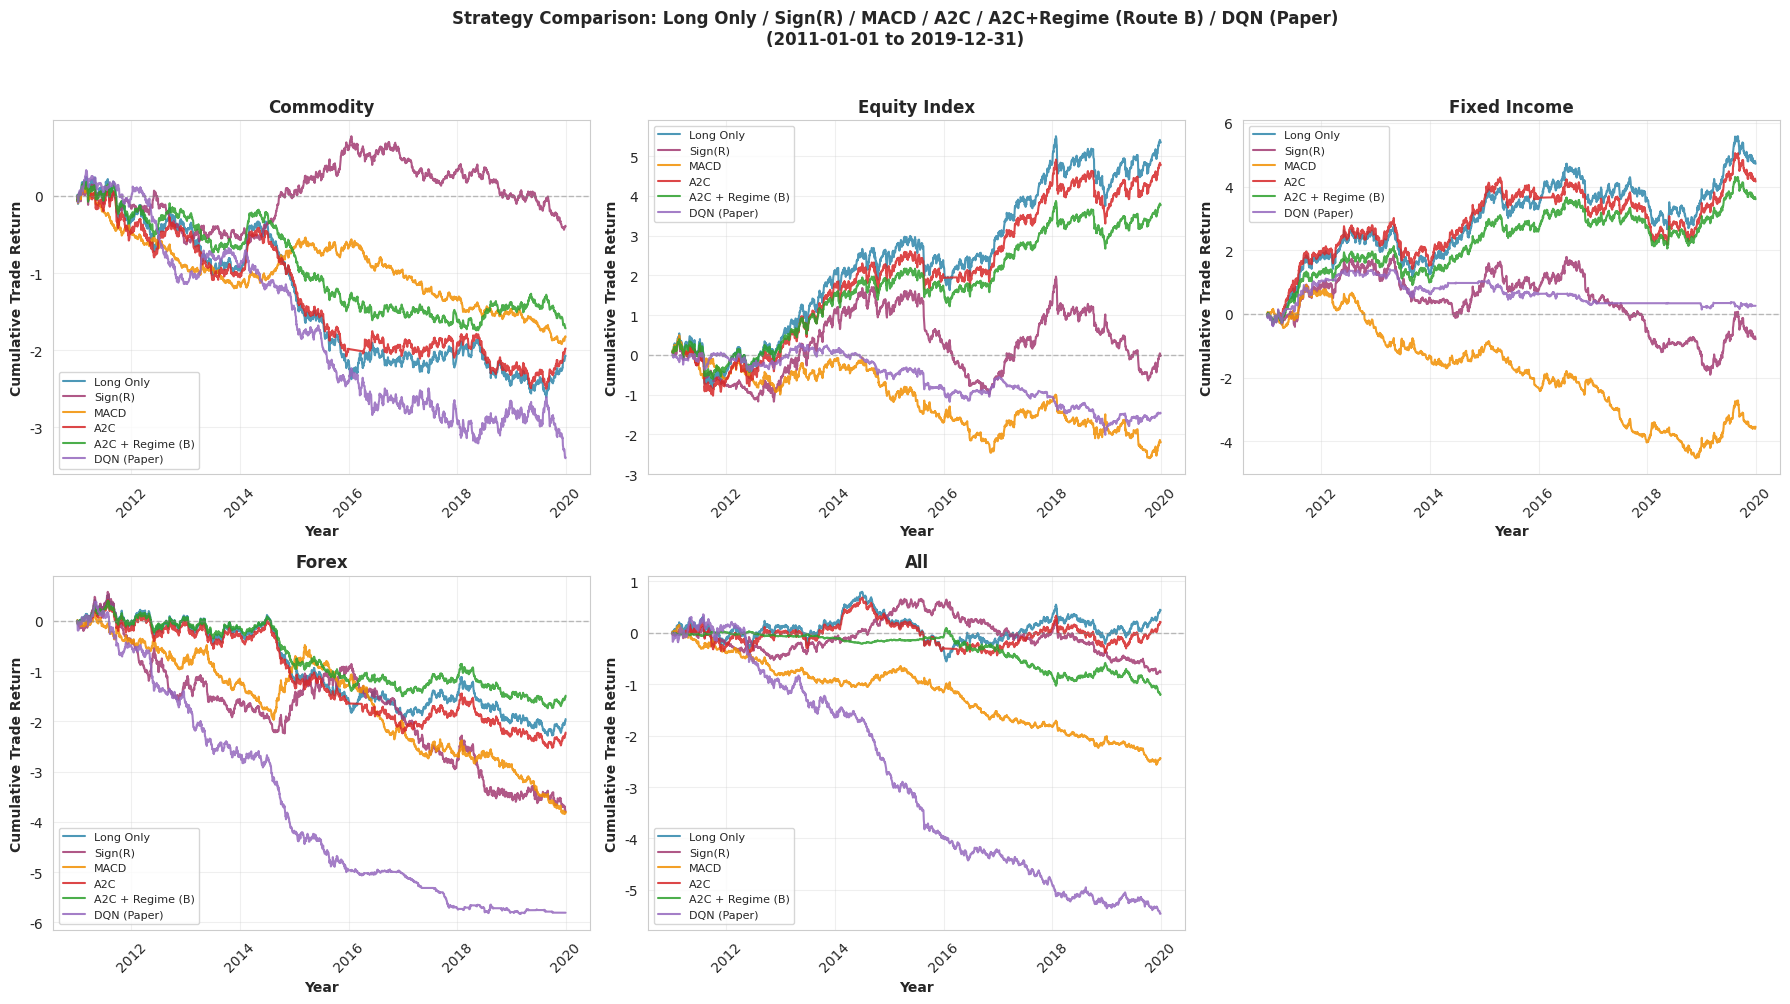

✅ Chart saved as strategies_with_route_b_and_dqn.png


In [281]:
import matplotlib.dates as mdates
print('📊 Plotting full comparison chart with Route B and paper DQN data...\n')

asset_order_plot = ASSET_CLASSES_LIST + ['All']

COLORS_FULL = {
    'Long Only':        '#2E86AB',
    'Sign(R)':          '#A23B72',
    'MACD':             '#F18F01',
    'A2C':              '#D62728',
    'A2C + Regime (B)': '#2CA02C',
    'DQN (Paper)':      '#9467BD',  # Paper DQN (purple, to distinguish from MACD orange)
}

all_strategy_data = {
    'Long Only':        baseline_results.get('Long Only', {}),
    'Sign(R)':          baseline_results.get('Sign(R)', {}),
    'MACD':             baseline_results.get('MACD', {}),
    'A2C':              a2c_wide_data,
    'A2C + Regime (B)': route_b_results,
    'DQN (Paper)':      dqn_results,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, asset in enumerate(asset_order_plot):
    ax = axes[idx]
    valid_data = {}

    for strategy, results in all_strategy_data.items():
        entry = results.get(asset, (None, None))
        dates_e, wealth_e = entry if isinstance(entry, tuple) else (None, None)
        if wealth_e is not None:
            valid_data[strategy] = (dates_e, wealth_e)

    if not valid_data:
        ax.text(0.5, 0.5, f'❌ {asset}\nData unavailable',
                ha='center', va='center', fontsize=12,
                transform=ax.transAxes, color='red')
        ax.set_title(asset, fontsize=12, fontweight='bold')
        continue

    uses_datetime_axis = False
    for strategy, (dates_e, wealth_e) in valid_data.items():
        # Uniform line width for all strategies, no special bolding for Route B
        lw    = 1.5
        alpha = 0.85

        if dates_e is not None and len(dates_e) > 0:
            try:
                # Ensure conversion to datetime, handling numpy datetime64 arrays
                if isinstance(dates_e, np.ndarray) and dates_e.dtype.kind == 'M':
                    aligned_dates = pd.to_datetime(dates_e)
                else:
                    aligned_dates = pd.to_datetime(dates_e)
                uses_datetime_axis = True
            except Exception as e:
                print(f"⚠️ Date conversion failed ({strategy}): {e}")
                aligned_dates = np.arange(len(wealth_e))
        else:
            aligned_dates = np.arange(len(wealth_e))

        # A2C and other strategies have different data formats
        # A2C: already cumulative return (starts from 0)
        # Route B and other strategies: wealth series (start from 1.0), subtract 1
        if strategy == 'A2C':
            plot_wealth_final = wealth_e  # A2C already starts from 0
        else:
            plot_wealth_final = wealth_e - 1.0  # Other strategies start from 1.0, subtract 1 to get cumulative return
        
        ax.plot(aligned_dates, plot_wealth_final,
                label=strategy,
                linewidth=lw,
                color=COLORS_FULL.get(strategy, '#888888'),
                alpha=alpha)

    ax.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cumulative Trade Return', fontsize=10, fontweight='bold')
    ax.set_title(asset, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8, frameon=True)
    ax.axhline(y=0.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    if uses_datetime_axis:
        ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)

for idx in range(len(asset_order_plot), len(axes)):
    axes[idx].axis('off')

plt.suptitle(
    'Strategy Comparison: Long Only / Sign(R) / MACD / A2C / A2C+Regime (Route B) / DQN (Paper)\n'
    f'({TEST_START} to {TEST_END})',
    fontsize=12, fontweight='bold', y=1.00
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
out_path = OUTPUT_DIR / 'strategies_with_route_b_and_dqn.png'
plt.savefig(str(out_path), dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Chart saved as {out_path.name}')